In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [3]:
import Modules.Background as bg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

In [4]:
cplot.general()

In [5]:
datasS0 = [np.load("background_data_profiles_lambda_n_case/sigma_1_Mult_%s.npy"%i, allow_pickle=True) for i in range(19)]

In [6]:
import matplotlib as mpl
import Modules.EnergyMass as en

from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap

In [7]:
# Checking that all configurations have the same mass up to the first decimal point.
LambT, gamma = 1, 0
datosTemp = []
datosMasa = []
print('#'*10)
for s0 in datasS0:
    MT, EnT = 0, 0
    pdata, temp = [], []
    for data in s0:
        Ei, rad, sDnew, dsDnew, uDnew, duDnew = data
        print(sDnew[0])
        Masa = en.massVal(rad, sDnew**2)
        arg2 = [LambT, gamma]  # Calculando la masa de la componente
        Enf, _, _ = en.EnFuncion([rad, sDnew, None], arg2)  # Calculando la energía de la componente
    
        MT += Masa  # Calculando la masa total
        EnT += Enf  # Calculando la energía total
        
        temp.append(Masa)
        pdata.append(sDnew[0])
        
    print('Masa = %4.3f'%MT)
    datosTemp.append(np.concatenate(([MT, EnT], pdata)))  # Guardando los datos
    datosMasa.append(temp)
print('#'*10)

datosSig0EnMas = []
datosSig0EnMas.append(np.array(datosTemp))  # Convierte y almacena los datos

##########
0.253
0.0
0.0
Masa = 25.447
0.2515625
0.007
0.0
Masa = 25.384
0.250125
0.016
0.0
Masa = 25.422
0.24725
0.023
0.0
Masa = 25.412
0.2415
0.0345
0.0
Masa = 25.480
0.23
0.047
0.0
Masa = 25.476
0.2185
0.056
0.0
Masa = 25.483
0.207
0.0625
0.0
Masa = 25.455
0.184
0.0725
0.0
Masa = 25.487
0.161
0.0782
0.0
Masa = 25.445
0.138
0.0815
0.0
Masa = 25.436
0.1265
0.0822


/Users/armandoroqueestrada/Proyecto_Proca/Stability/Modules/EnergyMass/energy_mass.py:134: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  Tval = 4 * np.pi * quad(intf, rmin, rfin)[0]


0.0
Masa = 25.416
0.115
0.0828
0.0
Masa = 25.467
0.1035
0.0824
0.0
Masa = 25.432
0.092
0.082
0.0
Masa = 25.488
0.069
0.079
0.0
Masa = 25.445
0.046
0.0745
0.0
Masa = 25.433
0.023
0.0693
0.0
Masa = 25.455
0.0
0.0665
0.0
Masa = 25.486
##########


In [8]:
# datosMasa
np.save("multif_P_masa_i", datosMasa)
np.save("multif_P_masa_En_pi", datosTemp)

In [9]:
def pert(lam, A, B, t=1):
    sigma = (A + B) * np.exp(lam * t) + np.conjugate((A - B))*np.exp(np.conjugate(lam) * t)
    return sigma

In [10]:
import Modules.SpectralMeth as sp
from scipy.interpolate import interp1d

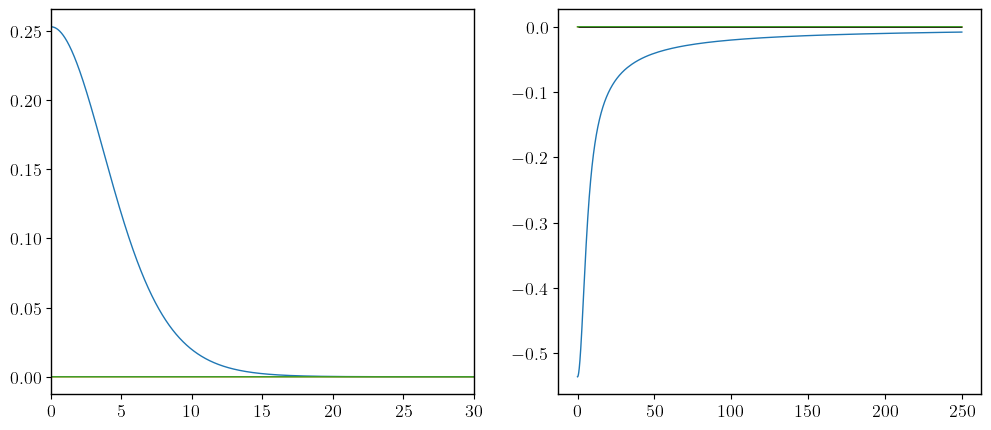

In [11]:
# perf 0
# Debo recuperar los resultados de la polarización linal con ln=1 con n=0

datE = []
datFunc = [[], []]
for s0dat in datasS0[0]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 0
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) # * 2

Jval = [0, 1, 2, 3, 4, 5]

lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
#ax[0].set_yscale('log')
plt.show()

lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [12]:
for ind, [Jval, data] in enumerate(dataExtra):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

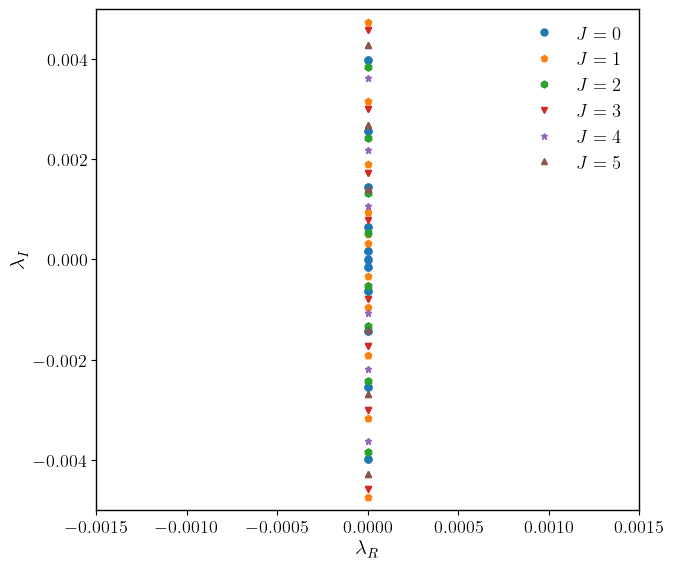

In [13]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5', "#43B72C", "#d723ce"]
mark = ['o', 'p', 'h', 'v',  '*', '^']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtra):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
ax.set_xlim(-0.0015, 0.0015)
ax.set_ylim(-.005, .005)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

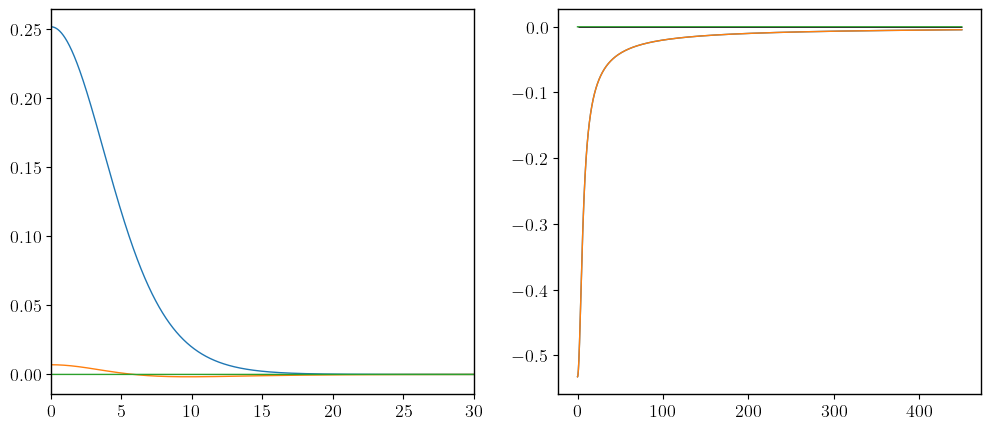

In [14]:
# perf 1

datE = []
datFunc = [[], []]
for s0dat in datasS0[1]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
#ax[0].set_yscale('log')
plt.show()

lambdaValn1, dataExtran1 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [15]:
for ind, [Jval, data] in enumerate(dataExtran1):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


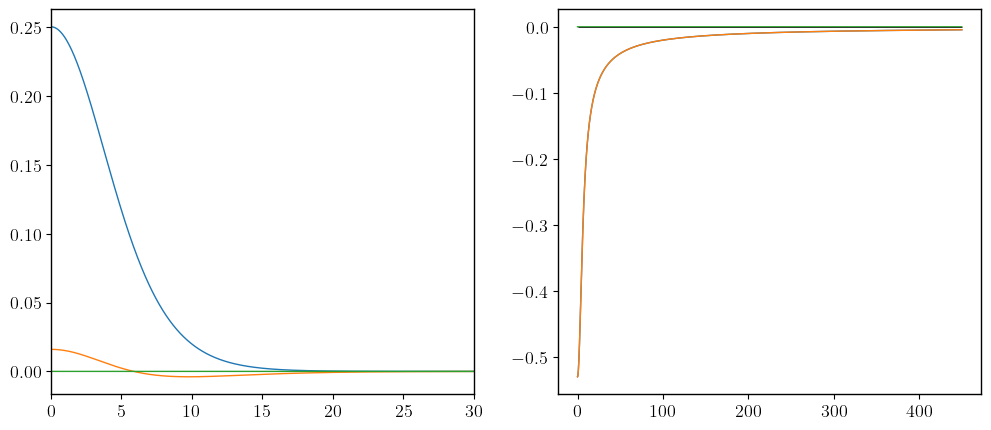

In [16]:
# perf 2
datE = []
datFunc = [[], []]
for s0dat in datasS0[2]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
# ax[0].set_yscale('log')
plt.show()

lambdaValn2, dataExtran2 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [17]:
for ind, [Jval, data] in enumerate(dataExtran2):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


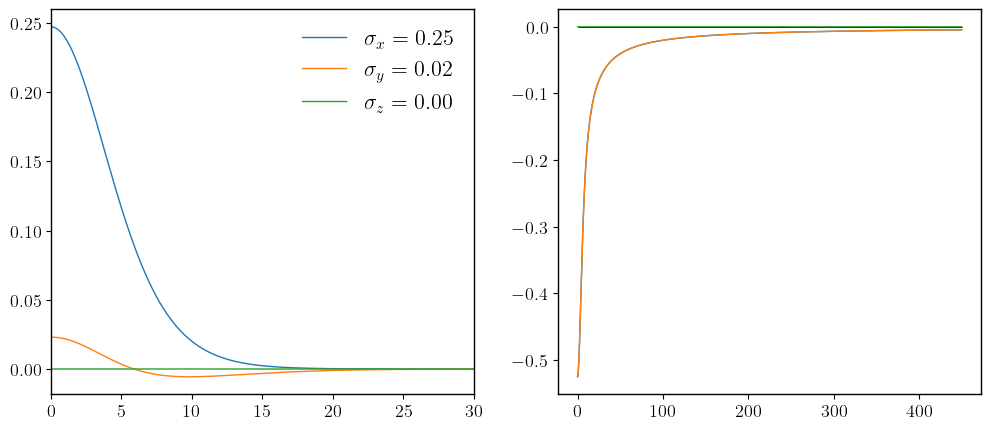

In [18]:
# perf 3
datE = []
datFunc = [[], []]
for s0dat in datasS0[3]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s = %3.2f$'%(label[i], datFunc[0][i](0)), lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
# ax[0].set_yscale('log')
ax[0].legend(frameon=False)
plt.show()

lambdaValn3, dataExtran3 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [19]:
for ind, [Jval, data] in enumerate(dataExtran3):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


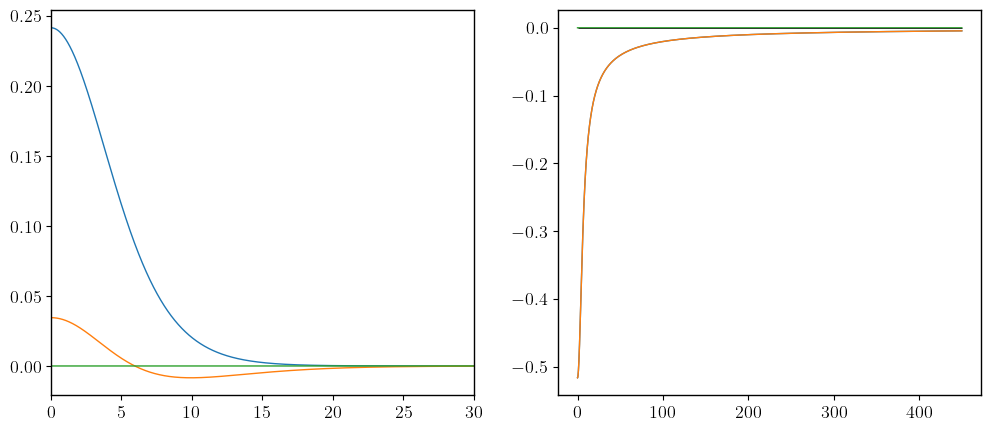

In [20]:
# perf 4

datE = []
datFunc = [[], []]
for s0dat in datasS0[4]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax /4 ) #* 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
#ax[0].set_yscale('log')
plt.show()

lambdaValn4, dataExtran4 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [21]:
for ind, [Jval, data] in enumerate(dataExtran4):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


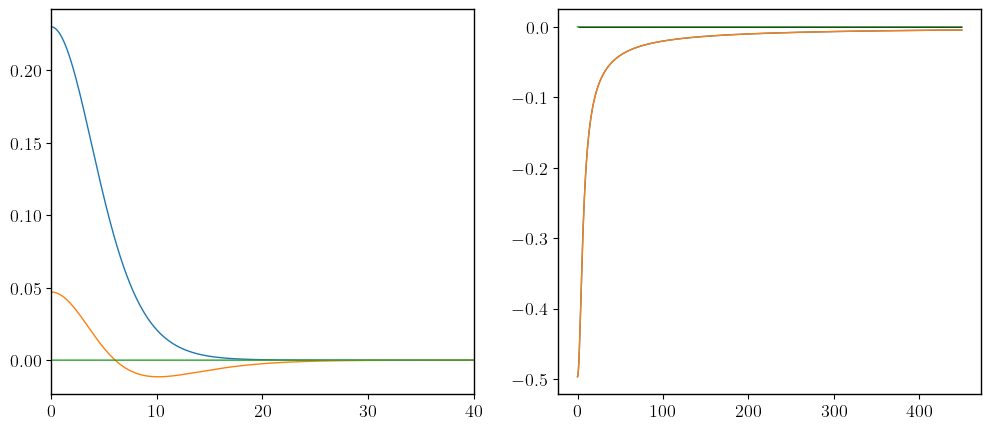

In [22]:
# perf 5
datE = []
datFunc = [[], []]
for s0dat in datasS0[5]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 40)
# ax[0].set_yscale('log')
plt.show()

lambdaValn5, dataExtran5 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [23]:
for ind, [Jval, data] in enumerate(dataExtran5):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


0.2185
0.056
0.0


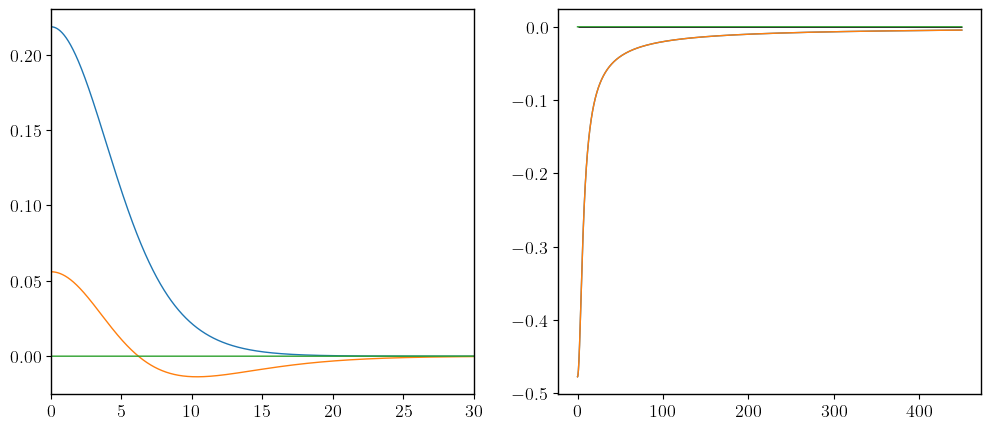

In [24]:
# perf 6

datE = []
datFunc = [[], []]
for s0dat in datasS0[6]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) #* 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    print(datFunc[0][i](0))
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
#ax[0].set_yscale('log')
plt.show()

lambdaValn6, dataExtran6 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [25]:
for ind, [Jval, data] in enumerate(dataExtran6):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


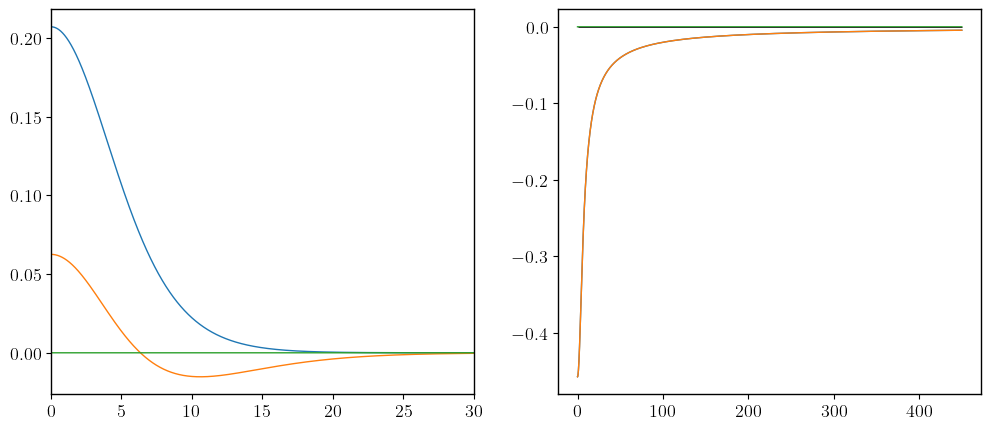

In [26]:
# perf 7

datE = []
datFunc = [[], []]
for s0dat in datasS0[7]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
#ax[0].set_yscale('log')
plt.show()

lambdaValn7, dataExtran7 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [27]:
for ind, [Jval, data] in enumerate(dataExtran7):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[-0.00113187-0.03773721j  0.00113187-0.03773721j  0.00113187+0.03773721j
 -0.00113187+0.03773721j]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

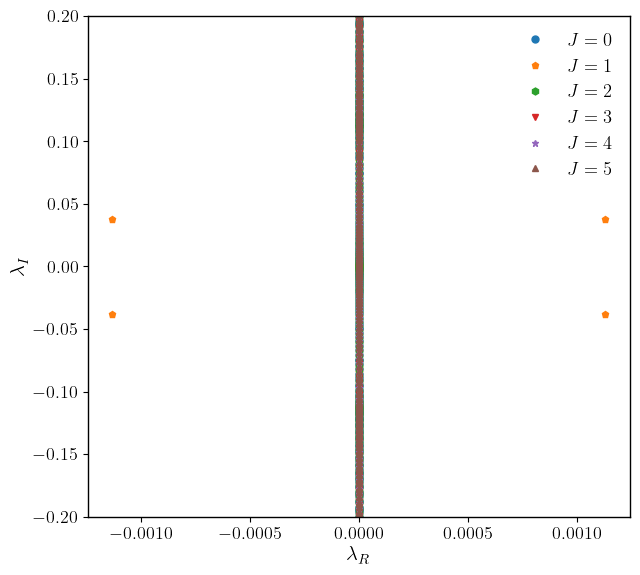

In [28]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5', "#43B72C", "#d723ce"]
mark = ['o', 'p', 'h', 'v',  '*', '^']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran7):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

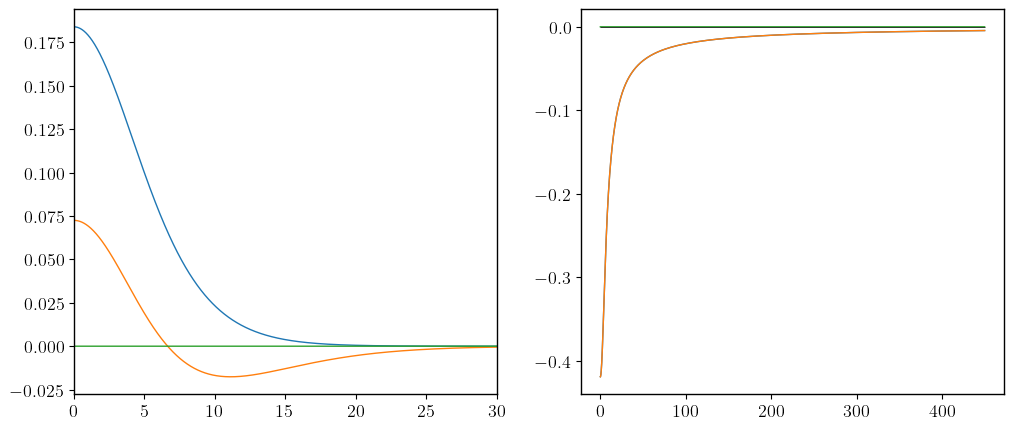

In [29]:
# perf 8

datE = []
datFunc = [[], []]
for s0dat in datasS0[8]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
#ax[0].set_yscale('log')
plt.show()

lambdaValn8, dataExtran8 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [30]:
for ind, [Jval, data] in enumerate(dataExtran8):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[ 0.00171601-0.03515609j -0.00171601-0.03515609j -0.00171601+0.03515609j
  0.00171601+0.03515609j]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

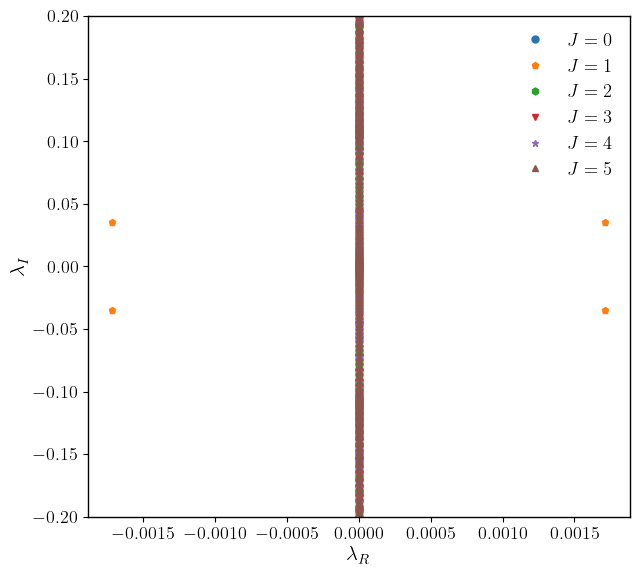

In [31]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5', "#43B72C", "#d723ce"]
mark = ['o', 'p', 'h', 'v',  '*', '^']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran8):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

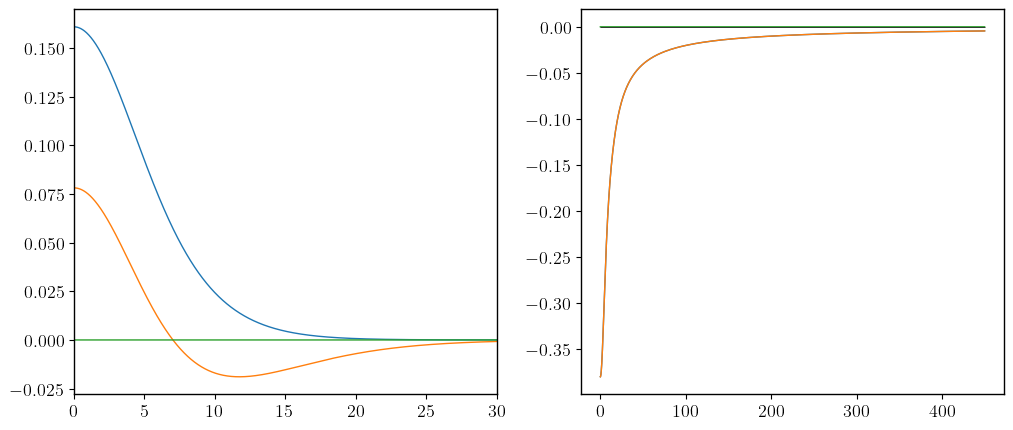

In [32]:
# perf 9

datE = []
datFunc = [[], []]
for s0dat in datasS0[9]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
# ax[0].set_yscale('log')
plt.show()

lambdaValn9, dataExtran9 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [33]:
for ind, [Jval, data] in enumerate(dataExtran9):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[-0.00172084-0.03248833j  0.00172084-0.03248833j -0.00172084+0.03248833j
  0.00172084+0.03248833j]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

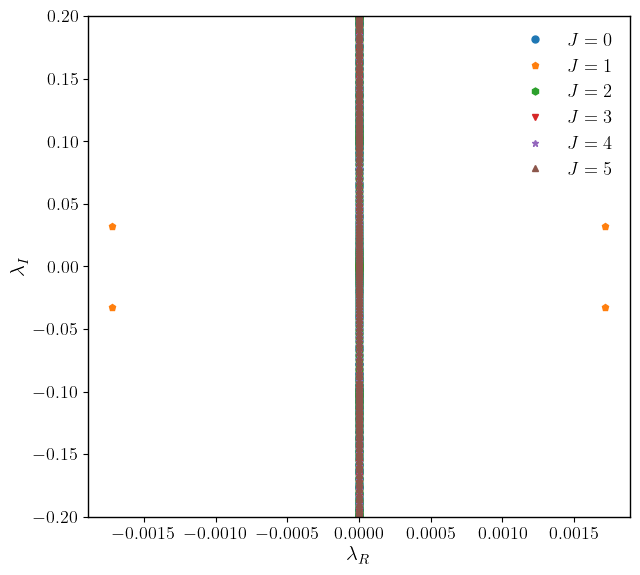

In [34]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5', "#43B72C", "#d723ce"]
mark = ['o', 'p', 'h', 'v',  '*', '^']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran9):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

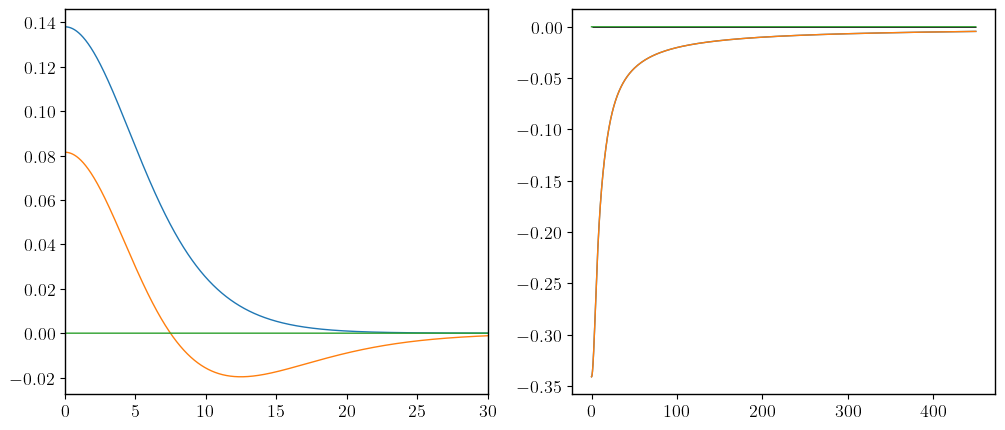

In [35]:
# perf 10

datE = []
datFunc = [[], []]
for s0dat in datasS0[10]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
#ax[0].set_yscale('log')
plt.show()

lambdaValn10, dataExtran10 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [36]:
for ind, [Jval, data] in enumerate(dataExtran10):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[-0.00134218-0.02984322j  0.00134218-0.02984322j  0.00134218+0.02984322j
 -0.00134218+0.02984322j]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

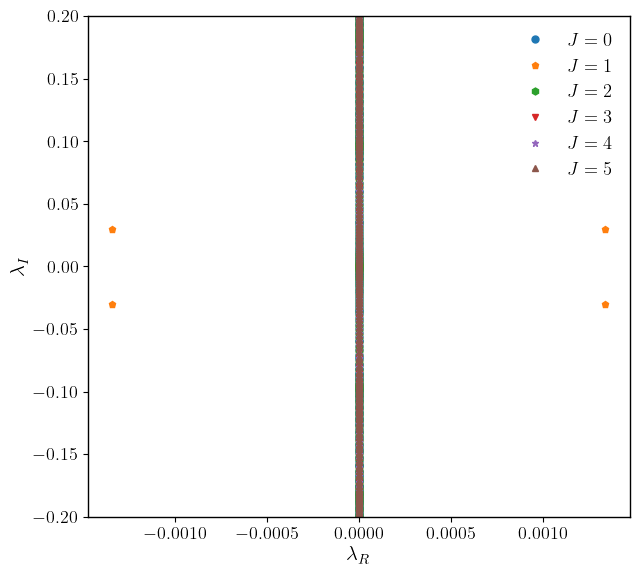

In [37]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5', "#43B72C", "#d723ce"]
mark = ['o', 'p', 'h', 'v',  '*', '^']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran10):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

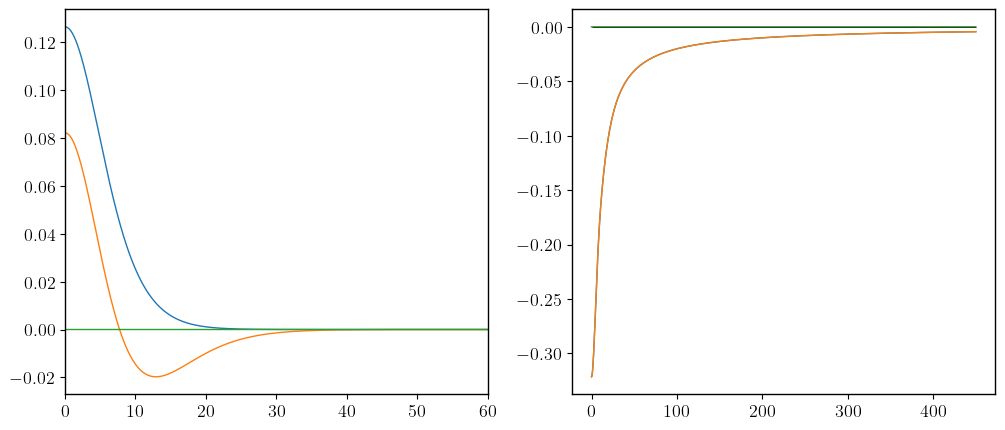

In [38]:
# perf 11

datE = []
datFunc = [[], []]
for s0dat in datasS0[11]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 60)
# ax[0].set_yscale('log')
plt.show()

lambdaValn11, dataExtran11 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [39]:
for ind, [Jval, data] in enumerate(dataExtran11):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[ 0.00094441-0.02849561j -0.00094441-0.02849561j  0.00094441+0.02849561j
 -0.00094441+0.02849561j]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

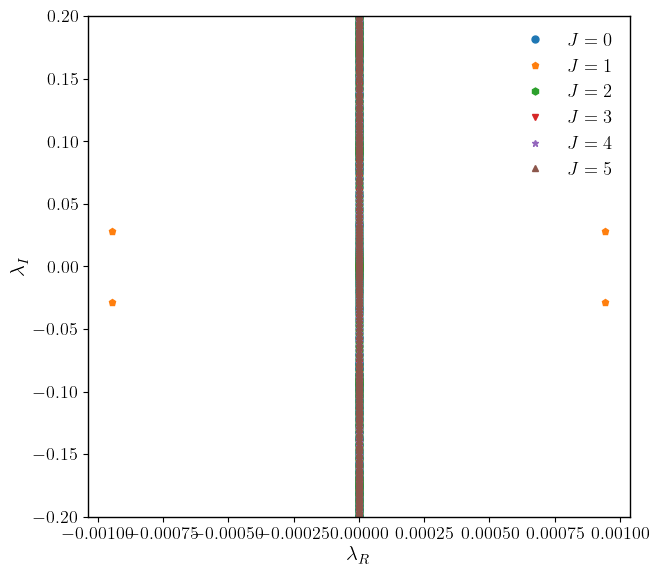

In [40]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5', "#43B72C", "#d723ce"]
mark = ['o', 'p', 'h', 'v',  '*', '^']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran11):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

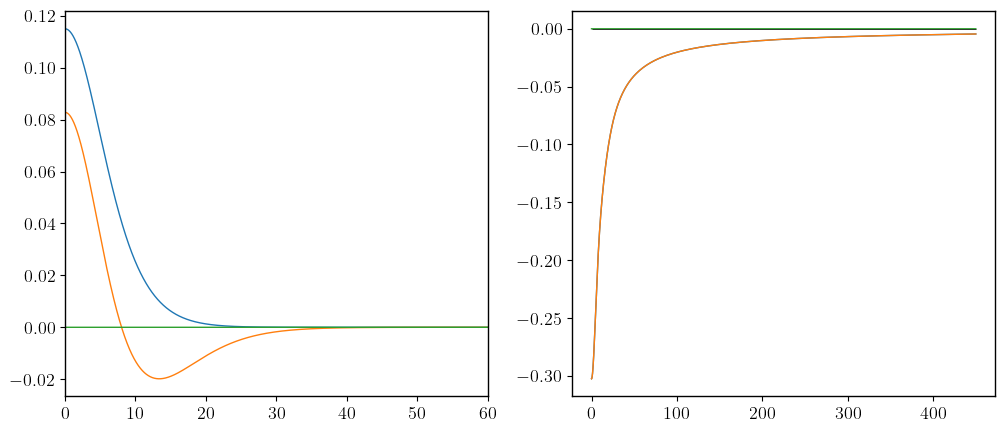

In [41]:
# perf 12

datE = []
datFunc = [[], []]
for s0dat in datasS0[12]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 60)
#ax[0].set_yscale('log')
plt.show()

lambdaValn12, dataExtran12 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [42]:
for ind, [Jval, data] in enumerate(dataExtran12):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

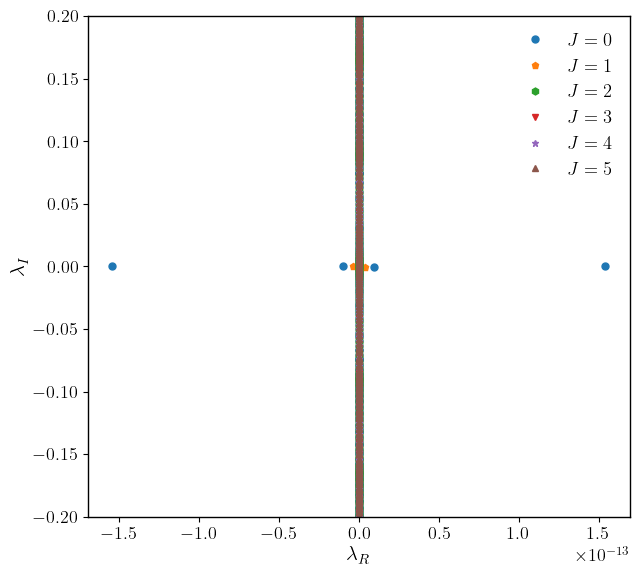

In [43]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5', "#43B72C", "#d723ce"]
mark = ['o', 'p', 'h', 'v',  '*', '^']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran12):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

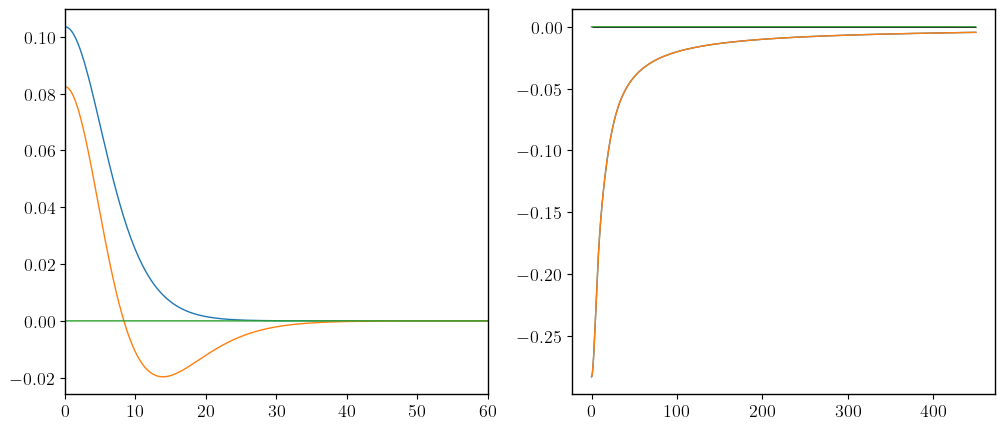

In [44]:
# perf 13

datE = []
datFunc = [[], []]
for s0dat in datasS0[13]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 60)
#ax[0].set_yscale('log')
plt.show()

lambdaValn13, dataExtran13 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [45]:
for ind, [Jval, data] in enumerate(dataExtran13):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[-0.00060604-0.07083927j  0.00060604-0.07083927j -0.00060604+0.07083927j
  0.00060604+0.07083927j]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

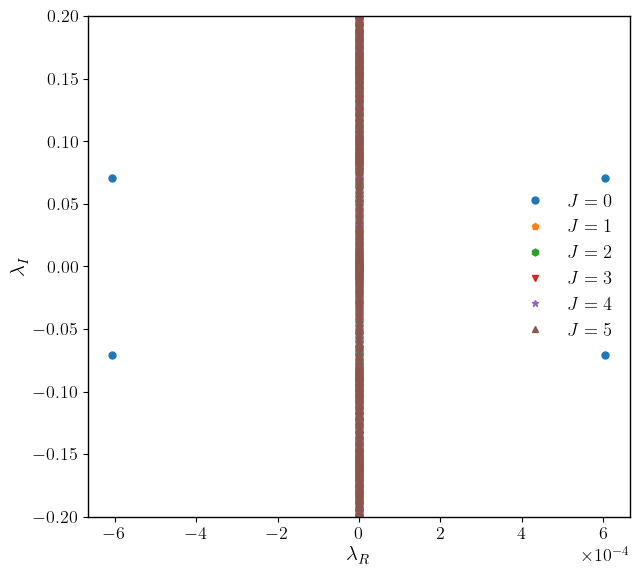

In [46]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5', "#43B72C", "#d723ce"]
mark = ['o', 'p', 'h', 'v',  '*', '^']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran13):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

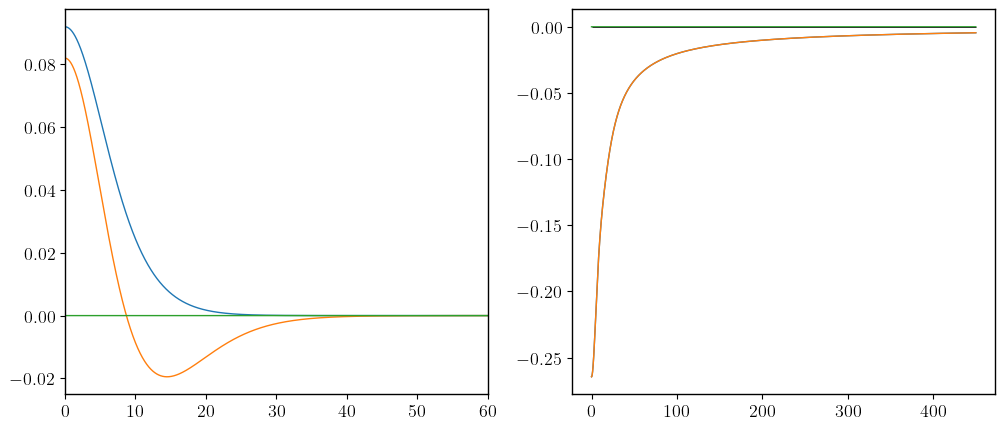

In [47]:
# perf 14

datE = []
datFunc = [[], []]
for s0dat in datasS0[14]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 60)
#ax[0].set_yscale('log')
plt.show()

lambdaValn14, dataExtran14 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [48]:
for ind, [Jval, data] in enumerate(dataExtran14):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[-0.00122084-0.06748465j  0.00122084-0.06748465j  0.00122084+0.06748465j
 -0.00122084+0.06748465j]
Jval = 1
[]
Jval = 2
[ 0.00229966-7.91419143e-17j -0.00229966-1.50422348e-16j]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

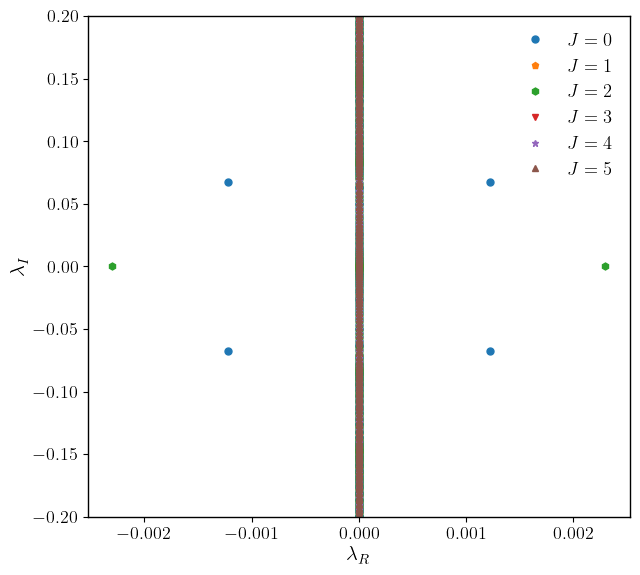

In [49]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5', "#43B72C", "#d723ce"]
mark = ['o', 'p', 'h', 'v',  '*', '^']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran14):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 6.5),
                       sharex=True, sharey=False,
                       gridspec_kw=dict(hspace=0.3, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )

# dataExtra.append([J, list([r_dis2, LambdaRealSorted, eig_vectors_sorted[:, jj]])])
for ind, [Jval, data] in enumerate(dataExtran12):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)    
    ind = np.abs(np.real(eingVal)) >= 1e-07 # filtrando los autovalores reales
    print(eingVal[ind])
    
    if Jval==2:
        labels = ['$A_{JM}^{r}$)', '$B_{JM}^{r})$', '$A_{JM}^{(1)}$', '$B_{JM}^{(1)}$', '$A_{JM}^{(2)}$', '$B_{JM}^{(2)}$']
        datay = (eigVect[:, ind])[:, 0]
        for i in range(6):
            ax[0][0].plot(rdis, np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Real(%s)'%labels[i])
            ax[0][1].plot(rdis, np.imag(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Im(%s)'%labels[i])

            if i%2 == 0:
                Ac = datay[i*(Nptos-1): (i+1)*(Nptos-1)]
                Bc = datay[(i+1)*(Nptos-1): (i+2)*(Nptos-1)]
                ax[0][0].plot(rdis, pert(eingVal[ind][0], Ac, Bc, t=1), 'k-', lw=3)
        
        ax[0][0].legend(frameon=False, fontsize='small', ncol=2)
        ax[0][1].legend(frameon=False, fontsize='small', ncol=2)
        
        datay = (eigVect[:, ind])[:, 1]
        for i in range(6):
            ax[1][0].plot(rdis, np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Real(%s)'%labels[i])
            ax[1][1].plot(rdis, np.imag(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Im(%s)'%labels[i])

            if i%2 == 0:
                Ac = datay[i*(Nptos-1): (i+1)*(Nptos-1)]
                Bc = datay[(i+1)*(Nptos-1): (i+2)*(Nptos-1)]
                ax[1][0].plot(rdis, pert(eingVal[ind][0], Ac, Bc, t=1), 'k-', lw=3)
        
        #ax[0][0].plot(rad2, np.abs(datFunc[0][0](rad2)), ls='--')
        
        ax[0][0].text(x=20, y=-0.05, s=r'%5.5f'%eingVal[ind][0])
        ax[1][0].text(x=20, y=-0.05, s=r'%5.5f'%eingVal[ind][1])
        ax[0][0].set_xlim(0, 30)
        ax[0][1].set_xlim(0, 30)

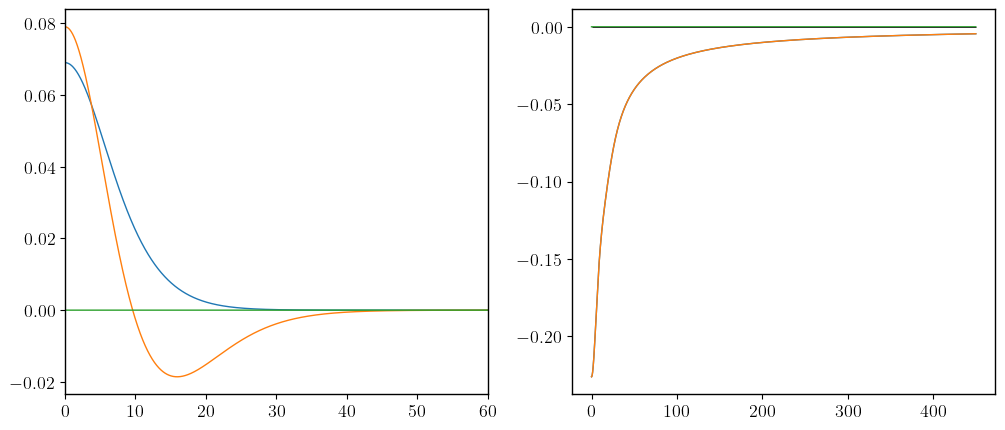

In [50]:
# perf 15

datE = []
datFunc = [[], []]
for s0dat in datasS0[15]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 60)
#ax[0].set_yscale('log')
plt.show()

lambdaValn15, dataExtran15 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [51]:
for ind, [Jval, data] in enumerate(dataExtran15):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[-0.00213492-0.05935587j  0.00213492-0.05935587j  0.00213492+0.05935587j
 -0.00213492+0.05935587j]
Jval = 1
[]
Jval = 2
[-0.00547862+3.73212426e-17j  0.00547862-2.13267800e-17j]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

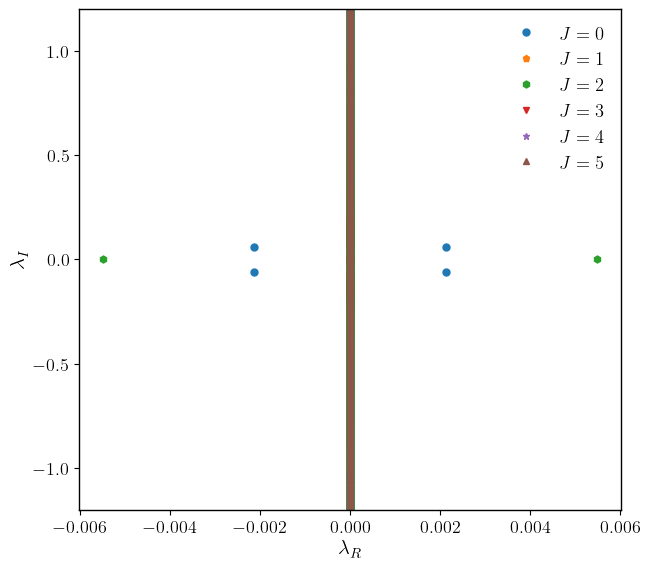

In [52]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5', "#43B72C", "#d723ce"]
mark = ['o', 'p', 'h', 'v',  '*', '^']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran15):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-1.2, 1.2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

In [ ]:
#rMax = 210 #200*(nodos+1) - 10
#Nptos = int(3*rMax/4) * 3

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 6.5),
                       sharex=True, sharey=False,
                       gridspec_kw=dict(hspace=0.3, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )

# dataExtra.append([J, list([r_dis2, LambdaRealSorted, eig_vectors_sorted[:, jj]])])
for ind, [Jval, data] in enumerate(dataExtran13):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)    
    ind = np.abs(np.real(eingVal)) >= 1e-07 # filtrando los autovalores reales
    print(eingVal[ind])
    
    if Jval==2:
        labels = ['$A_{JM}^{r}$)', '$B_{JM}^{r})$', '$A_{JM}^{(1)}$', '$B_{JM}^{(1)}$', '$A_{JM}^{(2)}$', '$B_{JM}^{(2)}$']
        datay = (eigVect[:, ind])[:, 0]
        for i in range(6):
            ax[0][0].plot(rdis, np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Real(%s)'%labels[i])
            ax[0][1].plot(rdis, np.imag(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Im(%s)'%labels[i])

            if i%2 == 0:
                Ac = datay[i*(Nptos-1): (i+1)*(Nptos-1)]
                Bc = datay[(i+1)*(Nptos-1): (i+2)*(Nptos-1)]
                ax[0][0].plot(rdis, pert(eingVal[ind][0], Ac, Bc, t=1), 'k-', lw=3)
        
        ax[0][0].legend(frameon=False, fontsize='small', ncol=2)
        ax[0][1].legend(frameon=False, fontsize='small', ncol=2)
        
        datay = (eigVect[:, ind])[:, 1]
        for i in range(6):
            ax[1][0].plot(rdis, np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Real(%s)'%labels[i])
            ax[1][1].plot(rdis, np.imag(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Im(%s)'%labels[i])

            if i%2 == 0:
                Ac = datay[i*(Nptos-1): (i+1)*(Nptos-1)]
                Bc = datay[(i+1)*(Nptos-1): (i+2)*(Nptos-1)]
                ax[1][0].plot(rdis, pert(eingVal[ind][0], Ac, Bc, t=1), 'k-', lw=3)
        
        #ax[0][0].plot(rad2, np.abs(datFunc[0][0](rad2)), ls='--')
        
        ax[0][0].text(x=20, y=-0.05, s=r'%5.5f'%eingVal[ind][0])
        ax[1][0].text(x=20, y=-0.05, s=r'%5.5f'%eingVal[ind][1])
        ax[0][0].set_xlim(0, 30)
        ax[0][1].set_xlim(0, 30)

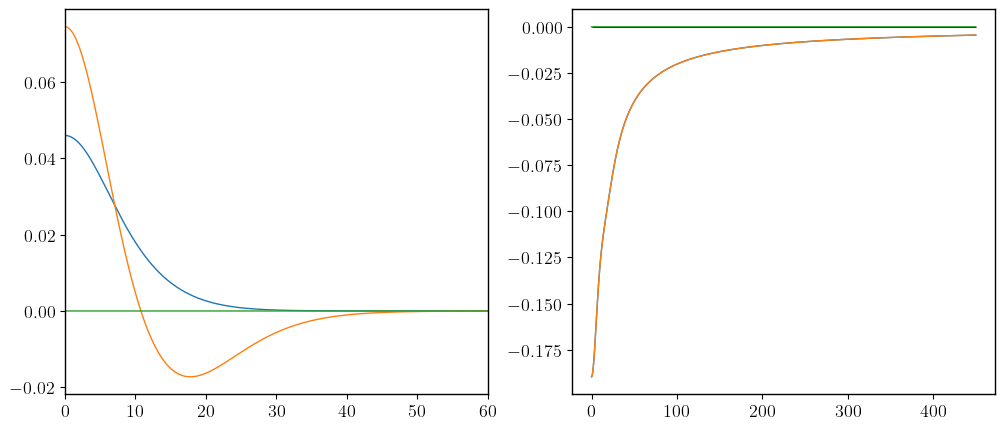

In [53]:
# perf 16

datE = []
datFunc = [[], []]
for s0dat in datasS0[16]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 60)
#ax[0].set_yscale('log')
plt.show()

lambdaValn16, dataExtran16 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [54]:
for ind, [Jval, data] in enumerate(dataExtran16):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[-0.00425992+0.05048168j  0.00425992+0.05048168j -0.00425992-0.05048168j
  0.00425992-0.05048168j]
Jval = 1
[]
Jval = 2
[ 0.00649107+1.15494201e-16j -0.00649107+1.90403825e-16j]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

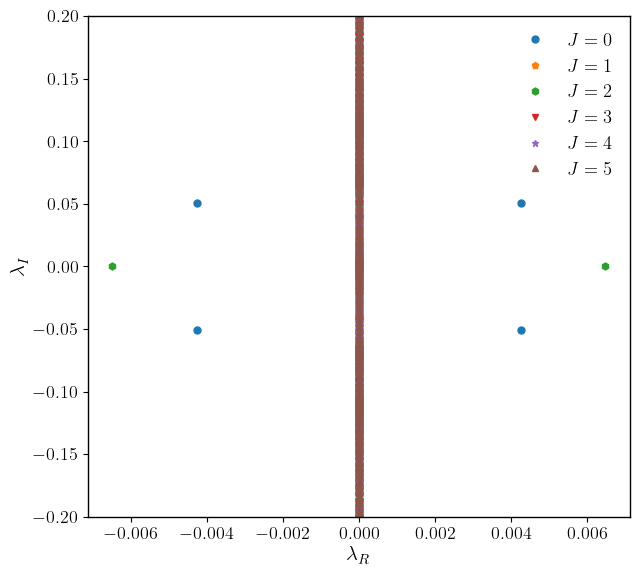

In [55]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5', "#43B72C", "#d723ce"]
mark = ['o', 'p', 'h', 'v',  '*', '^']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran16):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

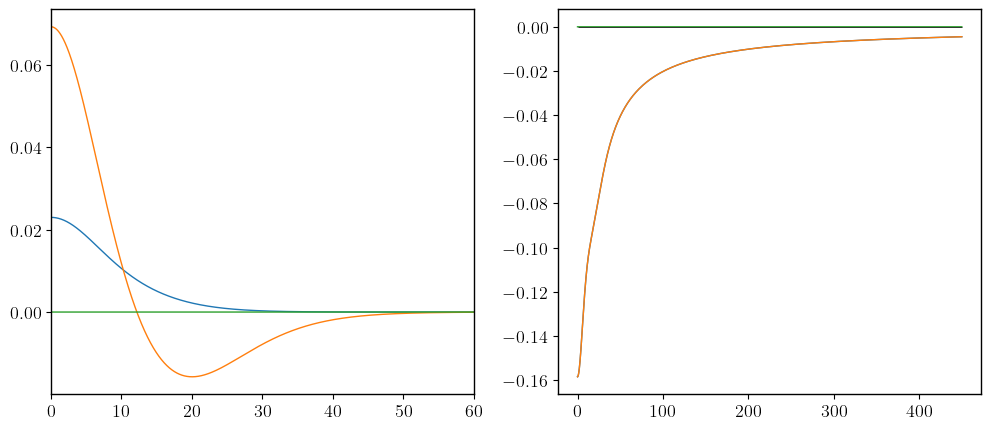

In [56]:
# perf 17

datE = []
datFunc = [[], []]
for s0dat in datasS0[17]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 60)
#ax[0].set_yscale('log')
plt.show()

lambdaValn17, dataExtran17 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [57]:
for ind, [Jval, data] in enumerate(dataExtran17):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[-0.00537687+0.0426279j  0.00537687+0.0426279j -0.00537687-0.0426279j
  0.00537687-0.0426279j]
Jval = 1
[]
Jval = 2
[-0.00663136+5.48045513e-17j  0.00663136-2.57067695e-18j]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

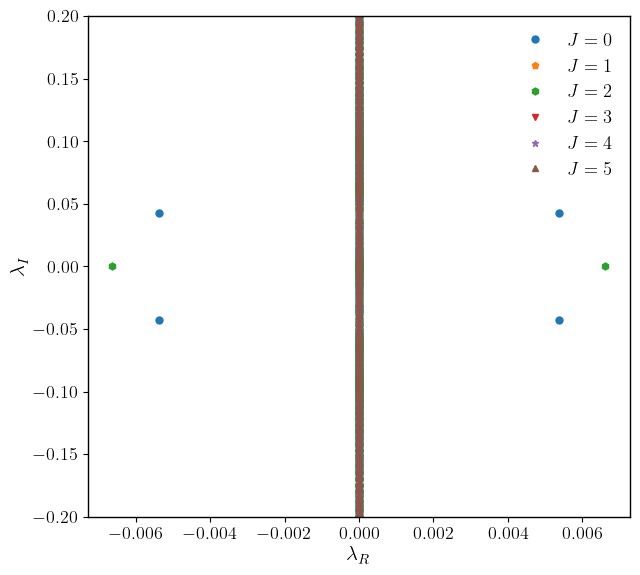

In [58]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5', "#43B72C", "#d723ce"]
mark = ['o', 'p', 'h', 'v',  '*', '^']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran17):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

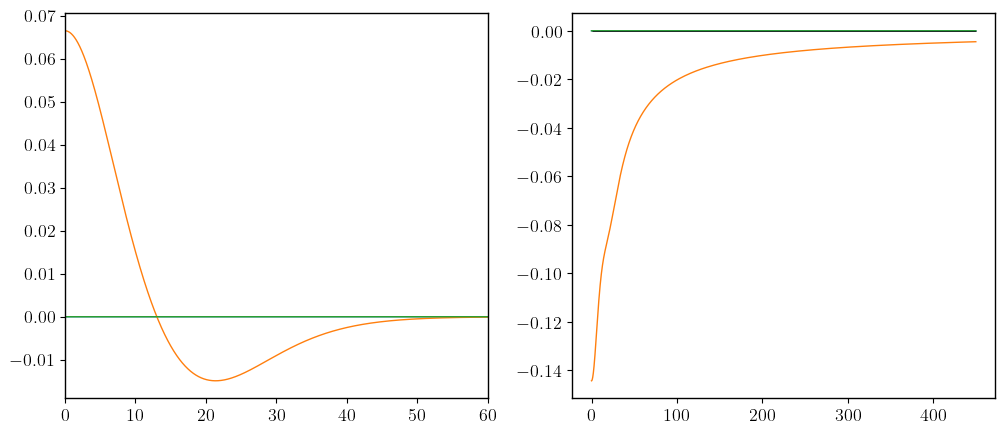

In [59]:
# perf 18

datE = []
datFunc = [[], []]
for s0dat in datasS0[18]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [1, 0]  # ln, ls
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 60)
#ax[0].set_yscale('log')
plt.show()

lambdaValn18, dataExtran18 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [60]:
for ind, [Jval, data] in enumerate(dataExtran18):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[-0.00555929-0.03876995j  0.00555929-0.03876995j  0.00555929+0.03876995j
 -0.00555929+0.03876995j]
Jval = 1
[]
Jval = 2
[-0.00651498-6.59526360e-16j  0.00651498-6.46687451e-16j]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

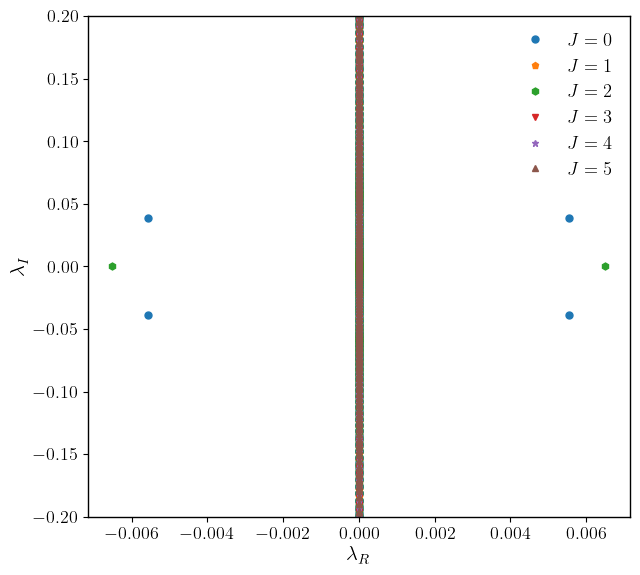

In [61]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5', "#43B72C", "#d723ce"]
mark = ['o', 'p', 'h', 'v',  '*', '^']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran18):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

In [62]:
# Eingevalues
data = [dataExtra, dataExtran1, dataExtran2, dataExtran3, dataExtran4, dataExtran5, dataExtran6,
        dataExtran7, dataExtran8, dataExtran9, dataExtran10, dataExtran11, dataExtran12, dataExtran13, dataExtran14,
        dataExtran15, dataExtran16, dataExtran17, dataExtran18] #, dataExtran19, dataExtran20, dataExtran21, dataExtran22, dataExtran23, dataExtran24]

In [63]:
temp = np.array(data, dtype="object")

In [64]:
JModes = [[], [], [], [], [], []]
JVect = [[], [], [], [], [], []]
for dat in data:
    for ind, [Jval, data2] in enumerate(dat):
        rdis, eingVal, eigVect = data2
        # print('Jval = %d'%Jval)
        ind2 = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
        # print(eingVal[ind2])
        
        JModes[ind].append(eingVal[ind2])
        JVect[ind].append([rdis, eigVect[:, ind]])

In [65]:
temp = np.array(JModes, dtype="object")
np.save("data_JModes_P", temp)

temp = np.array(JVect, dtype="object")
np.save("data_JVect_P", temp)

In [ ]:
# Plot

In [66]:
JModes = np.load("stability_lambda_n_case/Multifrequency/data_JModes_P.npy", allow_pickle=True)
JVect = np.load("stability_lambda_n_case/Multifrequency/data_JVect_P.npy", allow_pickle=True)
datosMasa = np.load("stability_lambda_n_case/Multifrequency/multif_P_masa_i.npy", allow_pickle=True)

In [67]:
totalM = np.sum(datosMasa, axis=1)
totalM

array([25.44747279, 25.38438148, 25.42231811, 25.4122048 , 25.4802177 ,
       25.47554575, 25.48303215, 25.45544448, 25.48696346, 25.44513527,
       25.43614788, 25.41584619, 25.46675295, 25.43236689, 25.48761022,
       25.44512497, 25.43325639, 25.4552073 , 25.4856932 ])

14 0.5782705844015068 [ 0.00229966-7.91419143e-17j -0.00229966-1.50422348e-16j]
15 0.6848586904268041 [-0.00547862+3.73212426e-17j  0.00547862-2.13267800e-17j]
16 0.8050246319573684 [ 0.00649107+1.15494201e-16j -0.00649107+1.90403825e-16j]
17 0.9309189409206807 [-0.00663136+5.48045513e-17j  0.00663136-2.57067695e-18j]
18 1.0 [-0.00651498-6.59526360e-16j  0.00651498-6.46687451e-16j]


Text(0.7, -0.028, '$\\lambda_n=1, \\lambda_s=0$')

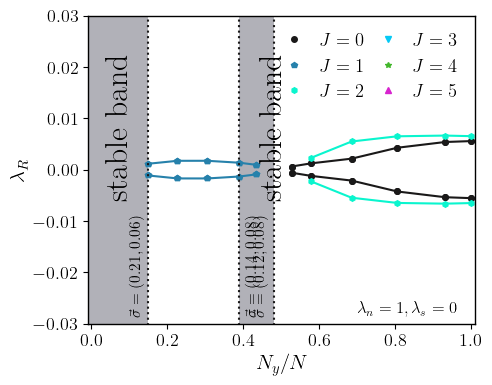

In [68]:
#col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5', "#43B72C", "#d723ce"]
mark = ['o', 'p', 'h', 'v',  '*', '^']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4.),
                       sharex=False, sharey=True,
                       gridspec_kw=dict(hspace=0.5, wspace=.15) # espacio vertical y horizontal entre los subplots
                      )

for i in range(6):
    tempP, tempN = [], []
    for j in range(len(totalM)):
        modos = JModes[i][j]
        ind2 = np.abs(np.real(modos)) >= 1e-6
        modos = modos[ind2]
        if len(modos) == 0:
            continue
        if i == 2:
            print(j, datosMasa[j][1]/totalM[j], modos)
        ax.plot([(datosMasa[j][1]/totalM[j])]*len(modos), np.real(modos), ls='', marker=mark[i], c=col[i], markersize='4')
        
        for mod in np.real(modos):
            if mod > 0:
                tempP.append([(datosMasa[j][1]/totalM[j]), mod])
            elif mod < 0:
                tempN.append([(datosMasa[j][1]/totalM[j]), mod])

    tempP = np.array(tempP, dtype="object")
    tempN = np.array(tempN, dtype="object")
    if tempP.size != 0 or tempN.size != 0:
        ax.plot(tempP[:, 0], tempP[:,1], ls='-', c=col[i])
        ax.plot(tempN[:, 0], tempN[:,1], ls='-', c=col[i])
    ax.plot([], [], ls='', marker=mark[i], c=col[i], markersize='4', label=r'$J=%d$'%i)
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.03, .03)
    ax.set_xlabel(r'$N_y/N$')    
ax.set_ylabel(r'$\lambda_R$')

jv = 12
xR = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax.text(x=xR-0.055, y=-0.028, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
ax.vlines(x=xR, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])
# ax.axvspan(xmin=xR, xmax=1.4, color=col[0], alpha=0.1)

jv = 7
xR1 = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax.text(x=xR1-0.05, y=-0.028, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
ax.vlines(x=xR1, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])
# ax.vlines(x=xR1, ymin=-0.2, ymax=0.2, ls='--', color=col[1], lw=1, alpha=1, zorder=10)

jv = 10
xR12 = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax.text(x=xR12 + 0.015, y=-0.028, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
ax.vlines(x=xR12, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])


ax.axvspan(-0.1, xR1, facecolor='#656473', alpha=0.5)
ax.axvspan(xR12, xR, facecolor='#656473', alpha=0.5)


ax.text(0.44, -0.005, s=r'stable band', rotation='vertical', fontsize='x-large')#, fontsize='small'
ax.text(0.035, -0.005, s=r'stable band', rotation='vertical', fontsize='x-large')
ax.legend(frameon=False, fontsize='small', loc='best', ncol=2, columnspacing=0.2, handletextpad=0.4)

ax.text(0.7, -0.028, s=r'$\lambda_n=1, \lambda_s=0$', fontsize=12)

In [107]:
for s0dat in datasS0[12]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    print(sDnew[0])

print()
for s0dat in datasS0[11]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    print(sDnew[0])

0.092
0.082
0.0

0.115
0.0828
0.0
